In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [17]:
keys = ["dgp", "statistic", "method", "n", "B", "repetitions"]

csv_reference = pd.read_csv("results_uz_es/results_uz_es.csv")
csv_new = pd.read_csv("results_eh_es/results_eh_es.csv")

In [18]:
# Merge the datasets so we can analyze the same cases
comparison = csv_new.merge(
    csv_reference, on=keys, suffixes=("_new", "_ref"), validate="one_to_one"
)

assert len(comparison) == len(csv_reference) and len(comparison) == len(
    csv_new
), "Experiments don't match!"

comparison.head(5)

,method,nominal_1_sided_coverage_new,nominal_2_sided_coverage_new,lower_coverage_new,upper_coverage_new,two_sided_coverage_new,mean_length_new,median_length_new,valid_interval_rate_new,n,...,B,repetitions,nominal_1_sided_coverage_ref,nominal_2_sided_coverage_ref,lower_coverage_ref,upper_coverage_ref,two_sided_coverage_ref,mean_length_ref,median_length_ref,valid_interval_rate_ref
0,percentile,0.975,0.95,0.947,0.941,0.888,1.232888,1.219378,1.0,8,...,1000,1000,0.975,0.95,0.948,0.949,0.897,1.249822,1.235576,1.0
1,double,0.975,0.95,0.972,0.968,0.940,1.680469,1.666507,1.0,8,...,1000,1000,0.975,0.95,0.972,0.973,0.945,1.695435,1.658536,1.0
2,percentile,0.975,0.95,0.963,0.966,0.929,0.675490,0.674467,1.0,32,...,1000,1000,0.975,0.95,0.968,0.970,0.938,0.680092,0.673639,1.0
3,double,0.975,0.95,0.967,0.979,0.946,0.721918,0.717315,1.0,32,...,1000,1000,0.975,0.95,0.973,0.974,0.947,0.725978,0.722371,1.0
4,percentile,0.975,0.95,0.979,0.982,0.961,0.344072,0.344171,1.0,128,...,1000,1000,0.975,0.95,0.974,0.958,0.932,0.346234,0.345725,1.0


In [ ]:
coverage_columns = ["lower_coverage", "upper_coverage", "two_sided_coverage"]

for column in coverage_columns:
    new = comparison[f"{column}_new"]
    ref = comparison[f"{column}_ref"]

    repetitions = comparison["repetitions"]

    comparison[f"{column}_difference"] = new - ref
    # Approximate SE assuming independent simulation results
    comparison[f"{column}_difference_se"] = np.sqrt(
        new * (1 - new) / repetitions + ref * (1 - ref) / repetitions
    )

    # Z score
    comparison[f"{column}_z"] = (
        comparison[f"{column}_difference"]
        / comparison[f"{column}_difference_se"]
    )

In [22]:
coverage_summary = pd.DataFrame(
    {
        column: {
            "mean_difference": comparison[f"{column}_difference"].mean(),
            "mean_absolute_difference": comparison[f"{column}_difference"]
            .abs()
            .mean(),
            "maximum_absolute_difference": comparison[f"{column}_difference"]
            .abs()
            .max(),
            "within_95pct_MC_range": (
                comparison[f"{column}_z"].abs() <= 1.96
            ).mean(),
        }
        for column in coverage_columns
    }
)
coverage_summary

,lower_coverage,upper_coverage,two_sided_coverage
mean_difference,0.001881,0.001190,0.003071
mean_absolute_difference,0.004881,0.007143,0.009405
maximum_absolute_difference,0.015000,0.026000,0.029000
within_95pct_MC_range,0.976190,0.904762,0.880952


In [25]:
comparison.loc[
    comparison["two_sided_coverage_z"].abs() > 1.96,
    [
        "dgp",
        "statistic",
        "method",
        "n",
        "two_sided_coverage_new",
        "two_sided_coverage_ref",
        "two_sided_coverage_difference",
        "two_sided_coverage_z",
    ],
].sort_values(
    "two_sided_coverage_z",
    key=abs,
    ascending=False,
)

,dgp,statistic,method,n,two_sided_coverage_new,two_sided_coverage_ref,two_sided_coverage_difference,two_sided_coverage_z
5,DGPNorm_0_1,mean,double,128,0.967,0.938,0.029,3.055731
4,DGPNorm_0_1,mean,percentile,128,0.961,0.932,0.029,2.887681
6,DGPNorm_0_1,median,percentile,8,0.935,0.910,0.025,2.092985
11,DGPNorm_0_1,median,double,128,0.957,0.936,0.021,2.089009
8,DGPNorm_0_1,median,percentile,32,0.958,0.938,0.020,2.016277


In [31]:
comparison.loc[
    comparison["upper_coverage_z"].abs() > 1.96,
    [
        "dgp",
        "statistic",
        "method",
        "n",
        "nominal_1_sided_coverage_new",
        "upper_coverage_new",
        "upper_coverage_ref",
        "upper_coverage_difference",
        "upper_coverage_z",
    ],
].sort_values(
    "upper_coverage_z",
    key=abs,
    ascending=False,
)

,dgp,statistic,method,n,nominal_1_sided_coverage_new,upper_coverage_new,upper_coverage_ref,upper_coverage_difference,upper_coverage_z
5,DGPNorm_0_1,mean,double,128,0.975,0.986,0.962,0.024,3.381959
4,DGPNorm_0_1,mean,percentile,128,0.975,0.982,0.958,0.024,3.153748
11,DGPNorm_0_1,median,double,128,0.975,0.977,0.959,0.018,2.289884
10,DGPNorm_0_1,median,percentile,128,0.975,0.976,0.959,0.017,2.146181


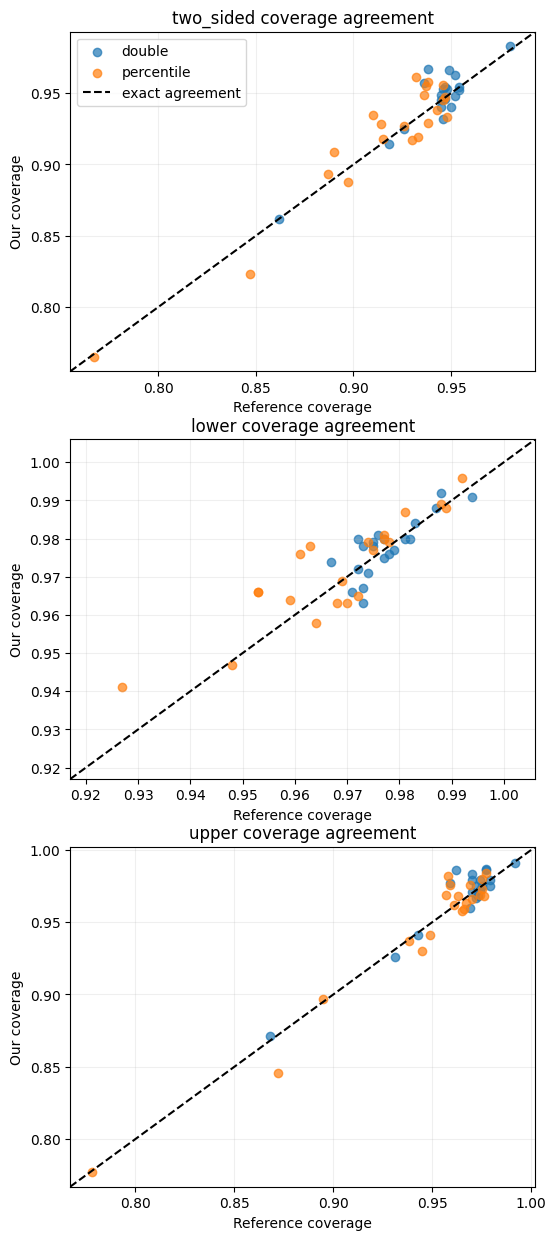

In [42]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(6, 15))

for i, side in enumerate(["two_sided", "lower", "upper"]):
    for method, group in comparison.groupby("method"):
        ax[i].scatter(
            group[f"{side}_coverage_ref"],
            group[f"{side}_coverage_new"],
            label=method,
            alpha=0.7,
        )

    limits = [
        min(
            comparison[f"{side}_coverage_ref"].min(),
            comparison[f"{side}_coverage_new"].min(),
        )
        - 0.01,
        max(
            comparison[f"{side}_coverage_ref"].max(),
            comparison[f"{side}_coverage_new"].max(),
        )
        + 0.01,
    ]

    ax[i].plot(limits, limits, "k--", label="exact agreement")
    ax[i].set(
        xlim=limits,
        ylim=limits,
        xlabel="Reference coverage",
        ylabel="Our coverage",
        title=f"{side} coverage agreement",
    )
    ax[i].grid(alpha=0.2)

ax[0].legend()

In [46]:
for column in ["mean_length", "median_length"]:
    comparison[f"{column}_ratio"] = (
        comparison[f"{column}_new"] / comparison[f"{column}_ref"]
    )

length_summary = pd.DataFrame(
    {
        column: {
            "mean_absolute_percent_difference": (
                comparison[f"{column}_ratio"] - 1
            )
            .abs()
            .mean()
            * 100,
            "maximum_absolute_percent_difference": (
                comparison[f"{column}_ratio"] - 1
            )
            .abs()
            .max()
            * 100,
        }
        for column in ["mean_length", "median_length"]
    }
)

length_summary

,mean_length,median_length
mean_absolute_percent_difference,0.841113,1.121961
maximum_absolute_percent_difference,2.405053,4.184601


In [ ]:
# Just check validity
assert comparison["valid_interval_rate_new"].eq(1).all()
assert comparison["valid_interval_rate_ref"].eq(1).all()

assert (
    (comparison["lower_coverage_new"] + comparison["upper_coverage_new"] - 1)
    .round(12)
    .eq(comparison["two_sided_coverage_new"])
    .all()
)

assert (
    (comparison["lower_coverage_ref"] + comparison["upper_coverage_ref"] - 1)
    .round(12)
    .eq(comparison["two_sided_coverage_ref"])
    .all()
)